# Lecture 10 (B08): Heterogeneous agents and Young's method

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §6.1-6.3 (Heterogeneous agents I), §6.4-6.6 (Heterogeneous agents II)  
**Notebook role:** core  
**Original live-course source:** `lectures/day4/code/10_Youngs_Method_Examples.ipynb`  
**Author:** Simon Scheidegger  

---

In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Young's (2010) Method to Simulate a Cross-Section

**Python implementation based on [Julien Pascal's notebook](https://julienpascal.github.io/post/young_2010/)**

---

**Reference:** Young, E.R. (2010). "Solving the incomplete markets model with aggregate uncertainty using the Krusell–Smith algorithm and non-stochastic simulations." *Journal of Economic Dynamics and Control*, 34(1), 36–41.

---

## Overview

Solving economic models with heterogeneous agents involves two key steps:
1. Finding the **optimal response of individuals** (policy functions)
2. **Simulating the model** to track how the cross-sectional distribution evolves

Young's (2010) method addresses step 2: instead of simulating a panel of agents (Monte Carlo), we simulate the **distribution directly** on a fixed grid — deterministically, with no sampling noise.

### Pedagogical role in Day 4
This notebook isolates the **Young update operator itself**. The companion notebook `11_Continuum_of_Agents_DEQN.ipynb` then uses the **same histogram logic** inside the larger Appendix A.5 DEQN teaching model. So the move from this notebook (10) to notebook 11 is a change in the surrounding equilibrium architecture, **not** a change in the distribution update method.

### This notebook demonstrates:
1. The core **mass redistribution** algorithm
2. Approximating a **single mass point**
3. Approximating a **multi-point distribution** (truncated normal)
4. **Mean preservation** property
5. Comparison with **panel-based simulation** (Monte Carlo)
6. **Convergence analysis**: how many agents does the panel approach need?
7. The conceptual bridge to the DEQN implementation in notebook 04

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# Plotting style
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. The Method

### Core idea

Choose a fixed grid $[w_1, w_2, \ldots, w_N]$ and represent the distribution as a **histogram** — a vector of masses at each grid point.

When a value $w$ falls between grid points $w_n$ and $w_{n+1}$, split its mass using **linear interpolation**:

$$p = 1 - \frac{w - w_n}{w_{n+1} - w_n}$$

- Mass assigned to $w_n$: $m \times p$
- Mass assigned to $w_{n+1}$: $m \times (1 - p)$

**Key property:** This preserves the mean exactly (when the grid is wide enough).

## 2. Helper Functions

In [2]:
def closest_index(grid, x):
    """Find the index of the closest grid point to x."""
    idx = np.searchsorted(grid, x)
    # Handle boundaries
    if idx == 0:
        return 0
    if idx == len(grid):
        return len(grid) - 1
    # Compare distances to neighbors
    if abs(grid[idx] - x) < abs(grid[idx - 1] - x):
        return idx
    else:
        return idx - 1


def redistribute_mass_single(w, mass, grid):
    """
    Redistribute a single mass point onto the grid using Young's method.
    
    Parameters
    ----------
    w : float
        True value of the mass point.
    mass : float  
        Amount of mass at this point.
    grid : array
        The fixed grid of points.
    
    Returns
    -------
    hw_grid : array
        Histogram of mass on the grid.
    """
    n = len(grid)
    hw_grid = np.zeros(n)
    w_min, w_max = grid[0], grid[-1]
    
    # Find closest grid point
    idx_proj = closest_index(grid, w)
    w_proj = grid[idx_proj]
    
    # Determine bracketing indices
    if w >= w_proj:
        idx_below = idx_proj
        idx_above = idx_proj + 1
    else:
        idx_below = idx_proj - 1
        idx_above = idx_proj
    
    # Boundary cases
    idx_below = np.clip(idx_below, 0, n - 1)
    idx_above = np.clip(idx_above, 0, n - 1)
    
    # Compute interpolation weight p
    if w <= w_min:
        p = 1.0  # all mass to first grid point
    elif w >= w_max:
        p = 0.0  # all mass to last grid point
    else:
        denom = grid[idx_above] - grid[idx_below]
        if denom == 0:
            p = 1.0
        else:
            p = 1.0 - (w - grid[idx_below]) / denom
            p = np.clip(p, 0.0, 1.0)
    
    # Spread the mass
    hw_grid[idx_below] += p * mass
    hw_grid[idx_above] += (1.0 - p) * mass
    
    return hw_grid


def redistribute_distribution(w_true, mass_true, grid):
    """
    Redistribute a multi-point distribution onto a grid using Young's method.
    
    Parameters
    ----------
    w_true : array
        Locations of the true mass points.
    mass_true : array
        Mass at each true point (should sum to 1).
    grid : array
        The fixed grid of points.
    
    Returns
    -------
    hw_grid : array
        Histogram of mass on the grid.
    """
    n = len(grid)
    hw_grid = np.zeros(n)
    
    for w, mass in zip(w_true, mass_true):
        hw_grid += redistribute_mass_single(w, mass, grid)
    
    return hw_grid


def weighted_mean(values, weights):
    """Compute the weighted mean."""
    return np.average(values, weights=weights)


def weighted_var(values, weights):
    """Compute the weighted variance."""
    mu = weighted_mean(values, weights)
    return np.average((values - mu) ** 2, weights=weights)


def weighted_quantile(values, weights, q):
    """Compute the weighted quantile."""
    sorted_idx = np.argsort(values)
    sorted_values = values[sorted_idx]
    sorted_weights = weights[sorted_idx]
    cum_weights = np.cumsum(sorted_weights)
    cum_weights /= cum_weights[-1]  # normalize
    return np.interp(q, cum_weights, sorted_values)

## 3. Example 1: Single Mass Point

Consider a single mass point at $w = 2.5$ with mass $m = 1.0$. The grid has 10 points equally spaced on $[0, 4]$.

Since $w = 2.5$ is not a grid point, Young's method splits the mass between the two nearest grid points.

Grid points: [0.         0.44444444 0.88888889 1.33333333 1.77777778 2.22222222
 2.66666667 3.11111111 3.55555556 4.        ]
Grid spacing: 0.4444


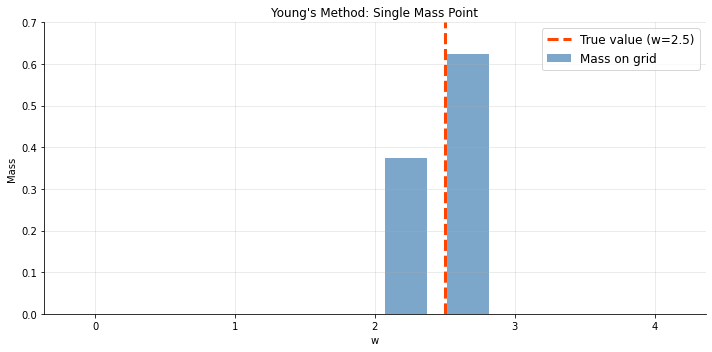

True mean:        2.5
Approximate mean: 2.5
Difference:       0.00e+00


In [3]:
# True value
w = 2.5
mass = 1.0

# Approximation grid
n_grid = 10
w_grid = np.linspace(0.0, 4.0, n_grid)
print(f"Grid points: {w_grid}")
print(f"Grid spacing: {w_grid[1] - w_grid[0]:.4f}")

# Redistribute
hw_grid = redistribute_mass_single(w, mass, w_grid)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(w_grid, hw_grid, width=0.3, alpha=0.7, color='steelblue', label='Mass on grid')
ax.axvline(w, color='orangered', linewidth=3, linestyle='--', label=f'True value (w={w})')
ax.set_xlabel('w')
ax.set_ylabel('Mass')
ax.set_title('Young\'s Method: Single Mass Point')
ax.legend(fontsize=12)
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

# Check mean preservation
true_mean = w
approx_mean = weighted_mean(w_grid, hw_grid)
print(f"True mean:        {true_mean}")
print(f"Approximate mean: {approx_mean}")
print(f"Difference:       {abs(true_mean - approx_mean):.2e}")

### What happened?

The true value $w = 2.5$ falls between grid points $w_5 \approx 2.22$ and $w_6 \approx 2.67$. The mass is split proportionally:

$$p = 1 - \frac{2.5 - 2.22}{2.67 - 2.22} \approx 0.375$$

So ~37.5% of the mass goes to $w_5$ and ~62.5% goes to $w_6$. The **mean is preserved exactly**.

## 4. Example 2: Multi-Point Distribution (Truncated Normal)

Now consider a more realistic case: the true distribution is a truncated normal on $[1, 3]$ with mean 2. We evaluate it at 10 equally spaced points, then project it onto a **different** (coarser or finer) grid.

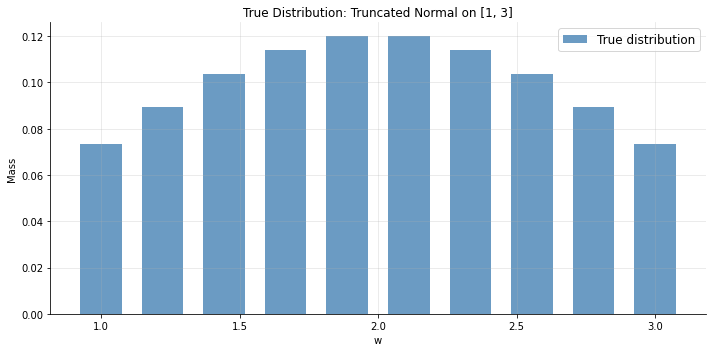

True mean:     2.0000
True median:   1.8889
True variance: 0.3465


In [4]:
# True distribution: truncated normal on [1, 3] centered at 2
# (Matching Method.pdf: Julia's Normal(2.0) has sigma=1.0 by default)
N_true = 10
w_true_lb, w_true_ub = 1.0, 3.0
mu_true = (w_true_lb + w_true_ub) / 2  # = 2.0
sigma_true = 1.0  # Julia default: Normal(mu) has sigma=1

# scipy's truncnorm uses standardized bounds
a_tn = (w_true_lb - mu_true) / sigma_true
b_tn = (w_true_ub - mu_true) / sigma_true
dist = truncnorm(a_tn, b_tn, loc=mu_true, scale=sigma_true)

# Evaluate at N_true equally spaced points
w_true = np.linspace(w_true_lb, w_true_ub, N_true)
mass_true = dist.pdf(w_true)
mass_true /= mass_true.sum()  # normalize to sum to 1

# Plot the true distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(w_true, mass_true, width=0.15, alpha=0.8, color='steelblue', label='True distribution')
ax.set_xlabel('w')
ax.set_ylabel('Mass')
ax.set_title('True Distribution: Truncated Normal on [1, 3]')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"True mean:     {weighted_mean(w_true, mass_true):.4f}")
print(f"True median:   {weighted_quantile(w_true, mass_true, 0.5):.4f}")
print(f"True variance: {weighted_var(w_true, mass_true):.4f}")

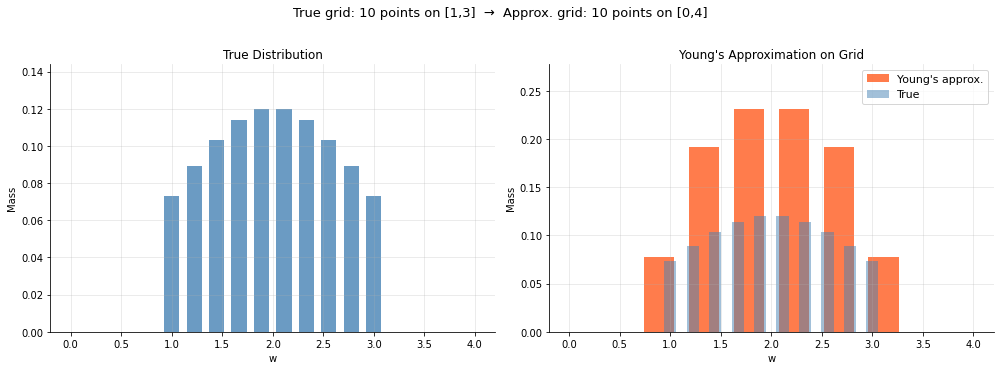

In [5]:
# Approximation grid: 10 points on [0, 4] (same as Method.pdf)
n_approx = 10
w_grid = np.linspace(0.0, 4.0, n_approx)

# Redistribute the true distribution onto the approximation grid
hw_grid = redistribute_distribution(w_true, mass_true, w_grid)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: true distribution
axes[0].bar(w_true, mass_true, width=0.15, alpha=0.8, color='steelblue')
axes[0].set_xlabel('w')
axes[0].set_ylabel('Mass')
axes[0].set_title('True Distribution')
axes[0].set_xlim(-0.2, 4.2)
axes[0].set_ylim(0, max(mass_true) * 1.2)

# Right: Young's approximation
axes[1].bar(w_grid, hw_grid, width=0.3, alpha=0.7, color='orangered', label="Young's approx.")
axes[1].bar(w_true, mass_true, width=0.12, alpha=0.5, color='steelblue', label='True')
axes[1].set_xlabel('w')
axes[1].set_ylabel('Mass')
axes[1].set_title("Young's Approximation on Grid")
axes[1].set_xlim(-0.2, 4.2)
axes[1].set_ylim(0, max(max(mass_true), max(hw_grid)) * 1.2)
axes[1].legend(fontsize=11)

plt.suptitle(f'True grid: {N_true} points on [1,3]  →  Approx. grid: {n_approx} points on [0,4]',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Compare moments
true_mean = weighted_mean(w_true, mass_true)
approx_mean = weighted_mean(w_grid, hw_grid)

true_median = weighted_quantile(w_true, mass_true, 0.5)
approx_median = weighted_quantile(w_grid, hw_grid, 0.5)

true_var = weighted_var(w_true, mass_true)
approx_var = weighted_var(w_grid, hw_grid)

print("Moment Comparison: Young's Method vs. True Distribution")
print("=" * 55)
print(f"{'':20s} {'True':>12s} {'Approx':>12s} {'Error':>12s}")
print("-" * 55)
print(f"{'Mean':20s} {true_mean:12.4f} {approx_mean:12.4f} {abs(true_mean-approx_mean):12.2e}")
print(f"{'Median':20s} {true_median:12.4f} {approx_median:12.4f} {abs(true_median-approx_median):12.2e}")
print(f"{'Variance':20s} {true_var:12.4f} {approx_var:12.4f} {abs(true_var-approx_var):12.2e}")
print("=" * 55)
print("\n→ Mean is preserved exactly; higher moments are approximated.")

Moment Comparison: Young's Method vs. True Distribution
                             True       Approx        Error
-------------------------------------------------------
Mean                       2.0000       2.0000     0.00e+00
Median                     1.8889       1.7778     1.11e-01
Variance                   0.3465       0.3836     3.70e-02

→ Mean is preserved exactly; higher moments are approximated.


## 5. Grid Refinement: Finer Grid → Better Approximation

The mean is always preserved, but higher moments (variance, median) improve with finer grids.

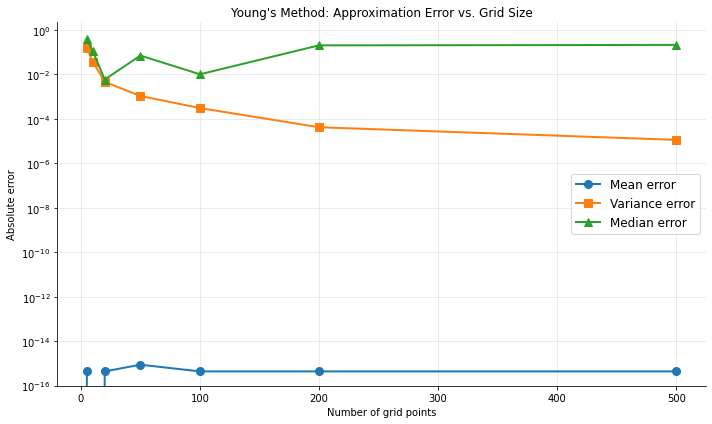

→ Mean error stays at machine precision regardless of grid size.
→ Variance and median errors decrease with finer grids.


In [7]:
grid_sizes = [5, 10, 20, 50, 100, 200, 500]
mean_errors = []
var_errors = []
median_errors = []

for ng in grid_sizes:
    g = np.linspace(0.0, 4.0, ng)
    h = redistribute_distribution(w_true, mass_true, g)
    
    mean_errors.append(abs(weighted_mean(g, h) - true_mean))
    var_errors.append(abs(weighted_var(g, h) - true_var))
    median_errors.append(abs(weighted_quantile(g, h, 0.5) - true_median))

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(grid_sizes, mean_errors, 'o-', linewidth=2, markersize=8, label='Mean error')
ax.semilogy(grid_sizes, var_errors, 's-', linewidth=2, markersize=8, label='Variance error')
ax.semilogy(grid_sizes, median_errors, '^-', linewidth=2, markersize=8, label='Median error')
ax.set_xlabel('Number of grid points')
ax.set_ylabel('Absolute error')
ax.set_title("Young's Method: Approximation Error vs. Grid Size")
ax.legend(fontsize=12)
ax.set_ylim(bottom=1e-16)
plt.tight_layout()
plt.show()

print("→ Mean error stays at machine precision regardless of grid size.")
print("→ Variance and median errors decrease with finer grids.")

## 6. Panel Simulation (Monte Carlo Alternative)

An alternative to Young's histogram method is to simulate a **panel of $N$ agents** drawn from the distribution. The law of large numbers ensures that, for large $N$, the sample moments converge to the true moments.

**But how large does $N$ need to be?**

Panel of 1000 agents:
                             True        Panel        Error
-------------------------------------------------------
Mean                       2.0000       1.9818       0.0182
Median                     1.8889       1.9945       0.1056
Variance                   0.3465       0.2980       0.0485


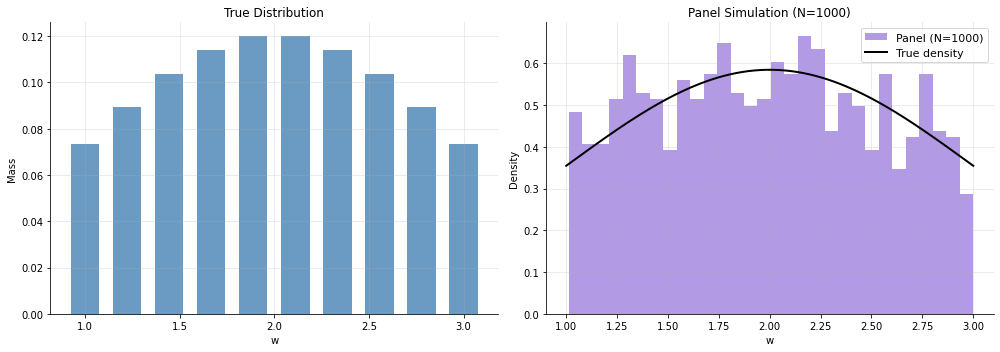

In [8]:
# Draw a panel of agents from the truncated normal
np.random.seed(SEED + 42)
nb_agents = 1000
w_agents = dist.rvs(size=nb_agents)

# Compare moments
panel_mean = np.mean(w_agents)
panel_median = np.median(w_agents)
panel_var = np.var(w_agents)

print(f"Panel of {nb_agents} agents:")
print(f"{'':20s} {'True':>12s} {'Panel':>12s} {'Error':>12s}")
print("-" * 55)
print(f"{'Mean':20s} {true_mean:12.4f} {panel_mean:12.4f} {abs(true_mean-panel_mean):12.4f}")
print(f"{'Median':20s} {true_median:12.4f} {panel_median:12.4f} {abs(true_median-panel_median):12.4f}")
print(f"{'Variance':20s} {true_var:12.4f} {panel_var:12.4f} {abs(true_var-panel_var):12.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(w_true, mass_true, width=0.15, alpha=0.8, color='steelblue', label='True distribution')
axes[0].set_xlabel('w')
axes[0].set_ylabel('Mass')
axes[0].set_title('True Distribution')

axes[1].hist(w_agents, bins=30, density=True, alpha=0.7, color='mediumpurple', label=f'Panel (N={nb_agents})')
# Overlay continuous true distribution
x_plot = np.linspace(w_true_lb, w_true_ub, 200)
axes[1].plot(x_plot, dist.pdf(x_plot), 'k-', linewidth=2, label='True density')
axes[1].set_xlabel('w')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Panel Simulation (N={nb_agents})')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

## 7. Panel Convergence: How Many Agents Are Needed?

We increase the panel size from 1,000 to 100,000 and track how the sample mean converges to the true mean. The key insight: **sampling error decays as $O(1/\sqrt{N})$** — you need a very large panel for accurate moments.

Young's method, by contrast, has **zero sampling error** for the mean.

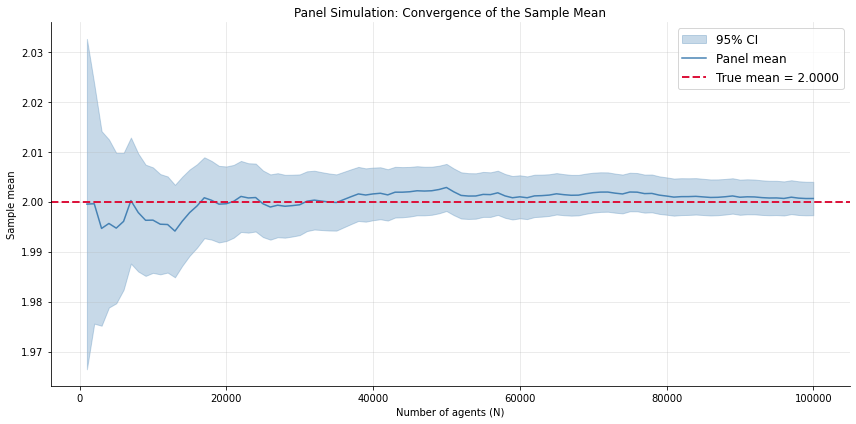

Panel mean at N=1,000:   1.999517   (error = 0.000483)
Panel mean at N=50,000:  2.002847   (error = 0.002847)
Panel mean at N=100,000: 2.000637   (error = 0.000637)

Young's method mean:     2.000000   (error = 0.00e+00)


In [9]:
np.random.seed(SEED + 123)

# Panel sizes to try
panel_sizes = np.arange(1000, 100_001, 1000)
mean_panel = np.zeros(len(panel_sizes))
std_panel = np.zeros(len(panel_sizes))

# For each panel size, draw agents and compute sample mean
# We use a single large draw and take prefixes for consistency
all_agents = dist.rvs(size=100_000)

for i, n in enumerate(panel_sizes):
    sample = all_agents[:n]
    mean_panel[i] = np.mean(sample)
    std_panel[i] = np.std(sample) / np.sqrt(n)  # standard error of the mean

# 95% confidence interval
ci = 1.96 * std_panel

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(panel_sizes, mean_panel - ci, mean_panel + ci,
                alpha=0.3, color='steelblue', label='95% CI')
ax.plot(panel_sizes, mean_panel, '-', linewidth=1.5, color='steelblue', label='Panel mean')
ax.axhline(true_mean, color='crimson', linewidth=2, linestyle='--', label=f'True mean = {true_mean:.4f}')
ax.set_xlabel('Number of agents (N)')
ax.set_ylabel('Sample mean')
ax.set_title('Panel Simulation: Convergence of the Sample Mean')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Panel mean at N=1,000:   {mean_panel[0]:.6f}   (error = {abs(mean_panel[0]-true_mean):.6f})")
print(f"Panel mean at N=50,000:  {mean_panel[49]:.6f}   (error = {abs(mean_panel[49]-true_mean):.6f})")
print(f"Panel mean at N=100,000: {mean_panel[-1]:.6f}   (error = {abs(mean_panel[-1]-true_mean):.6f})")
print(f"\nYoung's method mean:     {approx_mean:.6f}   (error = {abs(approx_mean-true_mean):.2e})")

## 8. Monte Carlo Comparison: Repeated Draws

To see the **sampling noise** more clearly, we repeat the panel simulation many times for different panel sizes and compare the standard deviation of the mean estimate.

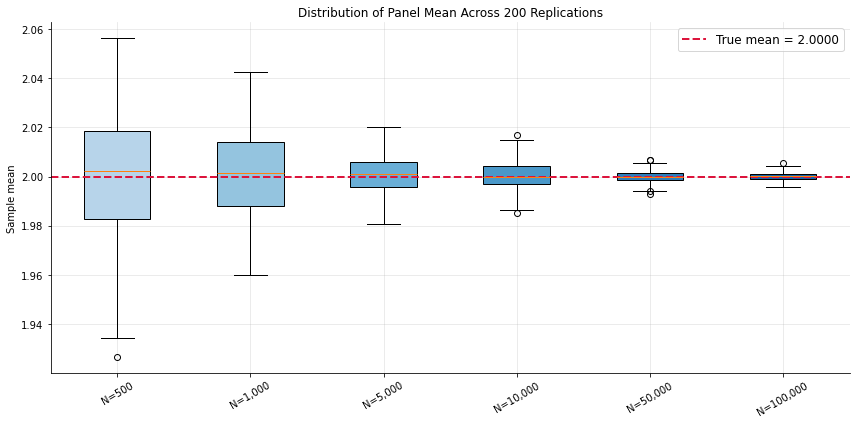

Standard deviation of mean estimate:
  N =     500: std = 0.024189
  N =   1,000: std = 0.016976
  N =   5,000: std = 0.008013
  N =  10,000: std = 0.005551
  N =  50,000: std = 0.002379
  N = 100,000: std = 0.001788

Young's method: std = 0 (deterministic)


In [10]:
np.random.seed(SEED + 456)

panel_sizes_mc = [500, 1000, 5000, 10_000, 50_000, 100_000]
n_replications = 200

results = {}
for n in panel_sizes_mc:
    means = np.array([np.mean(dist.rvs(size=n)) for _ in range(n_replications)])
    results[n] = means

fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(len(panel_sizes_mc))
bp = ax.boxplot([results[n] for n in panel_sizes_mc], positions=positions,
                widths=0.5, patch_artist=True, showfliers=True)

colors = plt.cm.Blues(np.linspace(0.3, 0.8, len(panel_sizes_mc)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.axhline(true_mean, color='crimson', linewidth=2, linestyle='--', label=f'True mean = {true_mean:.4f}')
ax.set_xticks(positions)
ax.set_xticklabels([f'N={n:,}' for n in panel_sizes_mc], rotation=30)
ax.set_ylabel('Sample mean')
ax.set_title(f'Distribution of Panel Mean Across {n_replications} Replications')
ax.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

print(f"Standard deviation of mean estimate:")
for n in panel_sizes_mc:
    print(f"  N = {n:>7,}: std = {np.std(results[n]):.6f}")
print(f"\nYoung's method: std = 0 (deterministic)")

## 9. Side-by-Side Comparison: Young vs. Panel

Let's directly compare the two approaches for approximating the distribution.

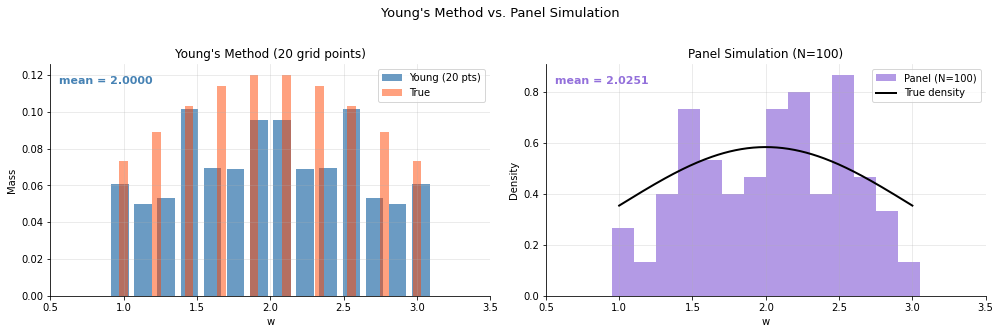

N =    100:  Panel mean error = 0.025053, Young mean error = 4.44e-16


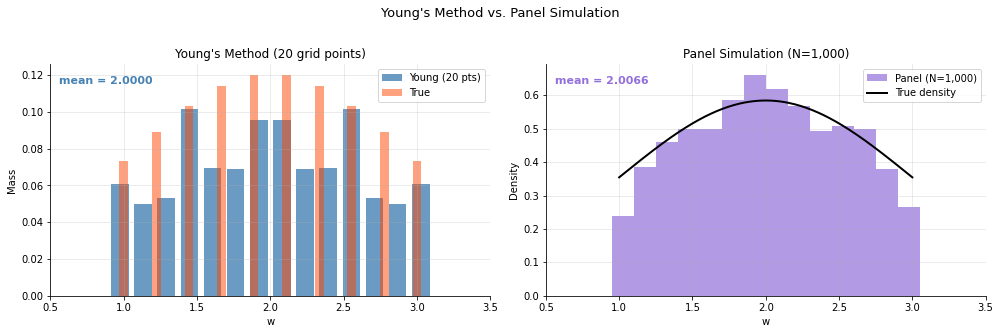

N =  1,000:  Panel mean error = 0.006575, Young mean error = 4.44e-16


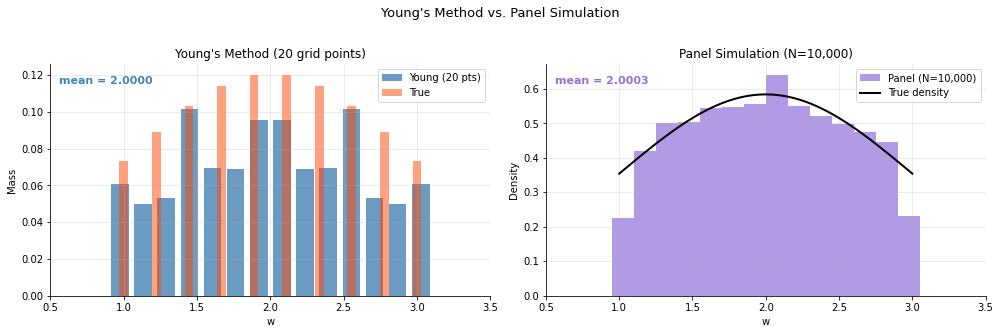

N = 10,000:  Panel mean error = 0.000303, Young mean error = 4.44e-16


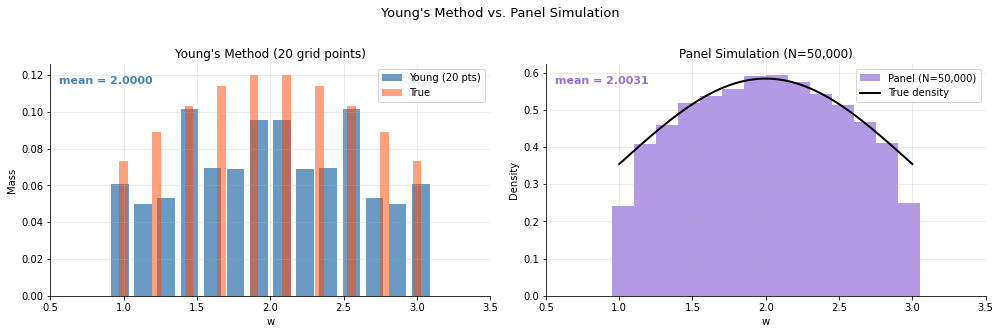

N = 50,000:  Panel mean error = 0.003061, Young mean error = 4.44e-16


In [11]:
np.random.seed(SEED + 789)

# Young's method with 20 grid points
n_young = 20
grid_young = np.linspace(0.5, 3.5, n_young)
hw_young = redistribute_distribution(w_true, mass_true, grid_young)

# Panel simulation with same number of "bins"
for n_panel in [100, 1_000, 10_000, 50_000]:
    w_panel = dist.rvs(size=n_panel)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    
    # Young's method
    axes[0].bar(grid_young, hw_young, width=0.12, alpha=0.8, color='steelblue',
                label=f"Young ({n_young} pts)")
    axes[0].bar(w_true, mass_true, width=0.06, alpha=0.5, color='orangered', label='True')
    axes[0].set_xlabel('w')
    axes[0].set_ylabel('Mass')
    axes[0].set_title(f"Young's Method ({n_young} grid points)")
    axes[0].legend(fontsize=10)
    axes[0].set_xlim(0.5, 3.5)
    
    # Panel histogram
    axes[1].hist(w_panel, bins=n_young, range=(0.5, 3.5), density=True, alpha=0.7,
                 color='mediumpurple', label=f'Panel (N={n_panel:,})')
    axes[1].plot(x_plot, dist.pdf(x_plot), 'k-', linewidth=2, label='True density')
    axes[1].set_xlabel('w')
    axes[1].set_ylabel('Density')
    axes[1].set_title(f'Panel Simulation (N={n_panel:,})')
    axes[1].legend(fontsize=10)
    axes[1].set_xlim(0.5, 3.5)
    
    # Annotate means
    young_mean = weighted_mean(grid_young, hw_young)
    panel_mean = np.mean(w_panel)
    axes[0].annotate(f'mean = {young_mean:.4f}', xy=(0.02, 0.95),
                     xycoords='axes fraction', fontsize=11, color='steelblue',
                     fontweight='bold', va='top')
    axes[1].annotate(f'mean = {panel_mean:.4f}', xy=(0.02, 0.95),
                     xycoords='axes fraction', fontsize=11, color='mediumpurple',
                     fontweight='bold', va='top')
    
    plt.suptitle(f'Young\'s Method vs. Panel Simulation', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"N = {n_panel:>6,}:  Panel mean error = {abs(panel_mean - true_mean):.6f}, "
          f"Young mean error = {abs(young_mean - true_mean):.2e}")

## 10. Summary Comparison Table

In [12]:
print("\n" + "=" * 70)
print("           Young's Method vs. Panel Simulation")
print("=" * 70)
print(f"{'Property':<30s} {'Young (2010)':<20s} {'Panel (MC)':<20s}")
print("-" * 70)
print(f"{'Sampling noise':<30s} {'None':<20s} {'O(1/√N)':<20s}")
print(f"{'Mean preservation':<30s} {'Exact':<20s} {'Approximate':<20s}")
print(f"{'Higher moments':<30s} {'Approximate':<20s} {'Approximate':<20s}")
print(f"{'Deterministic':<30s} {'Yes':<20s} {'No':<20s}")
print(f"{'Resolution needed':<30s} {'~100-5000 grid pts':<20s} {'~50,000+ agents':<20s}")
print(f"{'Computational cost':<30s} {'Low':<20s} {'Higher':<20s}")
print(f"{'Differentiable':<30s} {'Yes (for DEQNs)':<20s} {'No':<20s}")
print("=" * 70)


           Young's Method vs. Panel Simulation
Property                       Young (2010)         Panel (MC)          
----------------------------------------------------------------------
Sampling noise                 None                 O(1/√N)             
Mean preservation              Exact                Approximate         
Higher moments                 Approximate          Approximate         
Deterministic                  Yes                  No                  
Resolution needed              ~100-5000 grid pts   ~50,000+ agents     
Computational cost             Low                  Higher              
Differentiable                 Yes (for DEQNs)      No                  


## 11. Dynamic Application: Forward Simulation with a Policy Function

In a heterogeneous agent model, we use Young's method to propagate the distribution **forward in time** using the agents' policy functions. Here we demonstrate with a simple savings policy.

Consider agents with wealth $k$ who save according to:
$$k' = g(k) = s \cdot k + (1 - s) \cdot \bar{k}$$

This is a linear policy that pushes wealth toward the mean $\bar{k}$ at rate $(1-s)$.

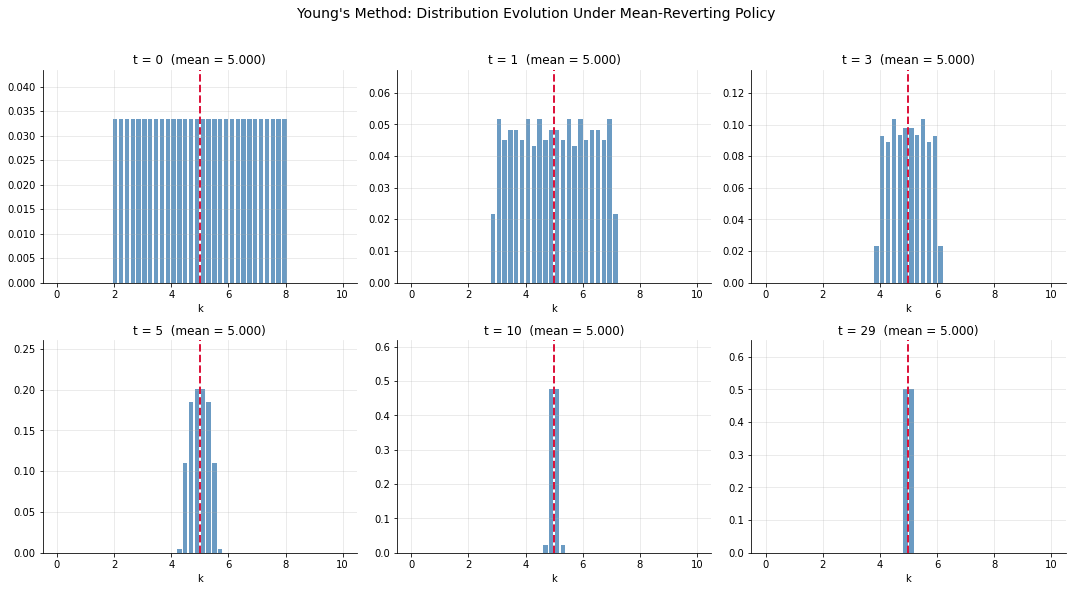

In [13]:
def forward_step_young(grid, hist, policy_func):
    """
    One forward step of Young's method.
    
    Given a histogram on a grid and a policy function k' = g(k),
    compute the next-period histogram.
    """
    n = len(grid)
    new_hist = np.zeros(n)
    
    for i in range(n):
        if hist[i] < 1e-15:
            continue
        
        # Compute next-period value
        k_prime = policy_func(grid[i])
        
        # Find bracketing grid points
        j = np.searchsorted(grid, k_prime) - 1
        j = np.clip(j, 0, n - 2)
        
        # Boundary handling
        if k_prime <= grid[0]:
            new_hist[0] += hist[i]
        elif k_prime >= grid[-1]:
            new_hist[-1] += hist[i]
        else:
            # Interpolation weight
            w = 1.0 - (k_prime - grid[j]) / (grid[j + 1] - grid[j])
            w = np.clip(w, 0.0, 1.0)
            new_hist[j] += w * hist[i]
            new_hist[j + 1] += (1.0 - w) * hist[i]
    
    return new_hist


# Setup
n_grid_dyn = 50
k_grid = np.linspace(0.0, 10.0, n_grid_dyn)

# Initial distribution: uniform on [2, 8]
h0 = np.zeros(n_grid_dyn)
mask = (k_grid >= 2.0) & (k_grid <= 8.0)
h0[mask] = 1.0
h0 /= h0.sum()

# Policy: mean-reverting savings
s = 0.7  # persistence
k_bar = 5.0  # steady-state capital
policy = lambda k: s * k + (1 - s) * k_bar

# Simulate T periods
T = 30
hists = [h0]
means = [weighted_mean(k_grid, h0)]

for t in range(T):
    h_new = forward_step_young(k_grid, hists[-1], policy)
    hists.append(h_new)
    means.append(weighted_mean(k_grid, h_new))

# Plot distribution evolution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_periods = [0, 1, 3, 5, 10, 29]
for ax, t_idx in zip(axes.flat, plot_periods):
    ax.bar(k_grid, hists[t_idx], width=0.15, color='steelblue', alpha=0.8)
    ax.axvline(means[t_idx], color='crimson', linewidth=2, linestyle='--')
    ax.set_title(f't = {t_idx}  (mean = {means[t_idx]:.3f})', fontsize=12)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(0, max(hists[t_idx]) * 1.3)
    ax.set_xlabel('k')

plt.suptitle("Young's Method: Distribution Evolution Under Mean-Reverting Policy",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

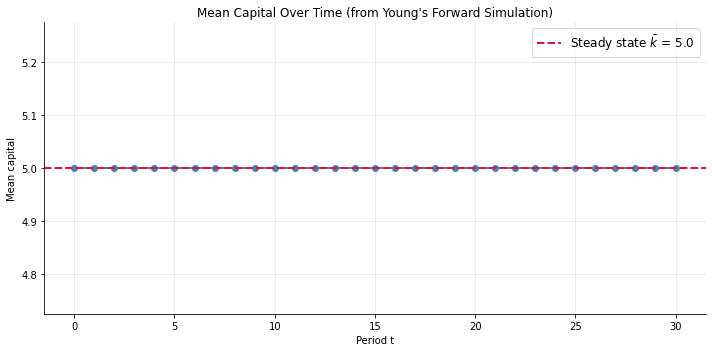

Mean at t=0:  5.000000
Mean at t=30: 5.000000
Steady state: 5.000000

→ Mean is preserved at 5.0 throughout (as expected for this symmetric policy).


In [14]:
# Plot mean evolution
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(T + 1), means, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axhline(k_bar, color='crimson', linewidth=2, linestyle='--', label=f'Steady state $\\bar{{k}}$ = {k_bar}')
ax.set_xlabel('Period t')
ax.set_ylabel('Mean capital')
ax.set_title('Mean Capital Over Time (from Young\'s Forward Simulation)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Mean at t=0:  {means[0]:.6f}")
print(f"Mean at t=30: {means[-1]:.6f}")
print(f"Steady state: {k_bar:.6f}")
print(f"\n→ Mean is preserved at {k_bar:.1f} throughout (as expected for this symmetric policy).")

## 12. With Idiosyncratic Shocks: Two Employment States

In a Krusell-Smith economy, agents face idiosyncratic employment shocks $\varepsilon \in \{e, u\}$. The histogram is now 2D: mass at each $(k, \varepsilon)$ pair. Young's method handles this by combining the policy-based mass redistribution with the Markov transition probabilities.

In [15]:
def forward_step_young_2d(grid, hist_2d, policy_funcs, trans_prob):
    """
    One forward step of Young's method with idiosyncratic shocks.
    
    Parameters
    ----------
    grid : array of shape (n_k,)
        Asset grid.
    hist_2d : array of shape (n_k, n_eps)
        Current histogram: hist_2d[i, j] = mass at (grid[i], eps_j).
    policy_funcs : list of callables
        policy_funcs[j](k) returns k' for employment state j.
    trans_prob : array of shape (n_eps, n_eps)
        Markov transition matrix: trans_prob[j, j'] = Prob(eps'=j' | eps=j).
    
    Returns
    -------
    new_hist : array of shape (n_k, n_eps)
    """
    n_k = len(grid)
    n_eps = hist_2d.shape[1]
    new_hist = np.zeros_like(hist_2d)
    
    for i in range(n_k):
        for eps in range(n_eps):
            if hist_2d[i, eps] < 1e-15:
                continue
            
            # Policy
            k_prime = policy_funcs[eps](grid[i])
            
            # Interpolation
            if k_prime <= grid[0]:
                j, w = 0, 1.0
            elif k_prime >= grid[-1]:
                j, w = n_k - 2, 0.0
            else:
                j = np.searchsorted(grid, k_prime) - 1
                j = np.clip(j, 0, n_k - 2)
                w = 1.0 - (k_prime - grid[j]) / (grid[j + 1] - grid[j])
                w = np.clip(w, 0.0, 1.0)
            
            # Redistribute across employment states
            for eps_next in range(n_eps):
                prob = trans_prob[eps, eps_next] * hist_2d[i, eps]
                new_hist[j, eps_next] += w * prob
                new_hist[j + 1, eps_next] += (1.0 - w) * prob
    
    return new_hist


# Setup
n_k = 100
k_grid = np.linspace(0.0, 20.0, n_k)

# Two employment states: employed (e) and unemployed (u)
# Transition matrix
pi_ee = 0.95  # prob staying employed
pi_uu = 0.90  # prob staying unemployed
trans_prob = np.array([
    [pi_ee, 1 - pi_ee],     # from employed
    [1 - pi_uu, pi_uu],     # from unemployed
])

# Policy functions (simple linear)
r = 0.04   # interest rate
w_e = 1.0  # wage when employed
w_u = 0.4  # wage when unemployed
delta = 0.05
s_rate = 0.3  # savings rate

policy_employed = lambda k: (1 + r - delta) * k * (1 - s_rate) + s_rate * ((1 + r - delta) * k + w_e)
# Simplify: k' = (1+r-delta)*k + w_e - c, where c = (1-s_rate)*((1+r-delta)*k + w_e)
# => k' = s_rate * ((1+r-delta)*k + w_e)
policy_e = lambda k: s_rate * ((1 + r - delta) * k + w_e)
policy_u = lambda k: s_rate * ((1 + r - delta) * k + w_u)

policy_funcs = [policy_e, policy_u]

# Initial distribution: everyone starts at k=5, half employed / half unemployed
hist_2d = np.zeros((n_k, 2))
idx_start = closest_index(k_grid, 5.0)
hist_2d[idx_start, 0] = 0.5  # employed
hist_2d[idx_start, 1] = 0.5  # unemployed

# Simulate
T = 100
hist_history = [hist_2d.copy()]
mean_k_history = [np.sum(k_grid[:, None] * hist_2d)]
frac_employed = [hist_2d[:, 0].sum()]

for t in range(T):
    hist_2d = forward_step_young_2d(k_grid, hist_2d, policy_funcs, trans_prob)
    hist_history.append(hist_2d.copy())
    mean_k_history.append(np.sum(k_grid[:, None] * hist_2d))
    frac_employed.append(hist_2d[:, 0].sum())

print(f"Stationary fraction employed: {frac_employed[-1]:.4f}")
print(f"  (Theoretical: {(1-pi_uu)/((1-pi_ee)+(1-pi_uu)):.4f})")
print(f"Mean capital at t={T}: {mean_k_history[-1]:.4f}")

Stationary fraction employed: 0.6667
  (Theoretical: 0.6667)
Mean capital at t=100: 0.3414


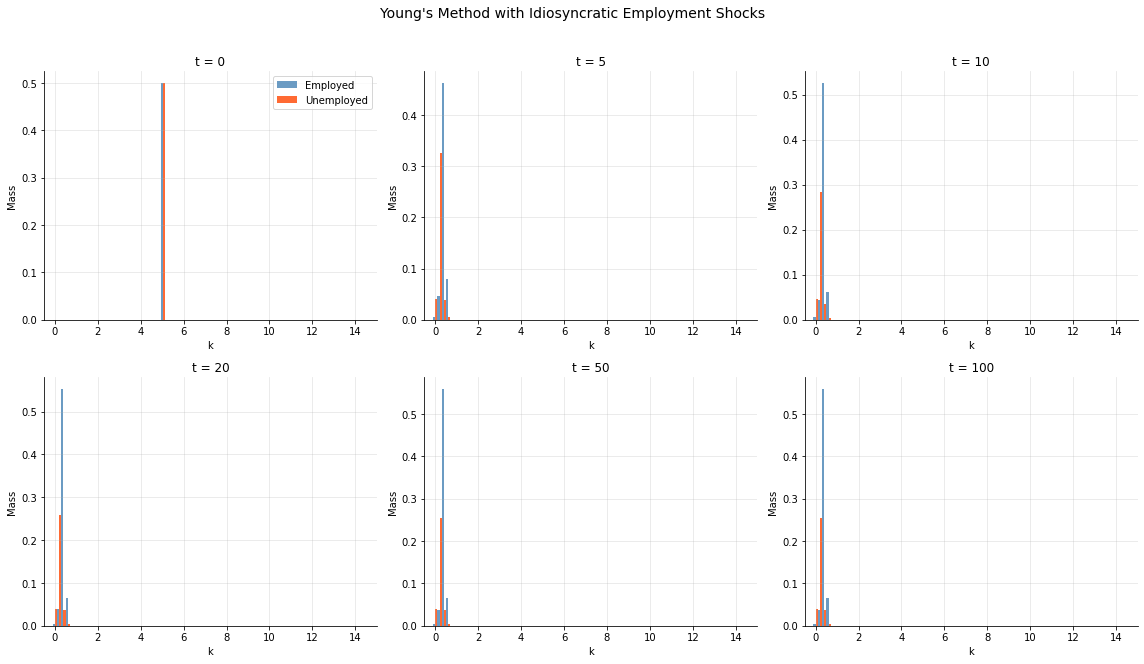

In [16]:
# Plot evolution of the 2D distribution
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_periods = [0, 5, 10, 20, 50, 100]

for ax, t_idx in zip(axes.flat, plot_periods):
    h = hist_history[t_idx]
    ax.bar(k_grid - 0.05, h[:, 0], width=0.1, alpha=0.8, color='steelblue', label='Employed')
    ax.bar(k_grid + 0.05, h[:, 1], width=0.1, alpha=0.8, color='orangered', label='Unemployed')
    ax.set_title(f't = {t_idx}', fontsize=12)
    ax.set_xlim(-0.5, 15)
    ax.set_xlabel('k')
    ax.set_ylabel('Mass')
    if t_idx == 0:
        ax.legend(fontsize=10)

plt.suptitle("Young's Method with Idiosyncratic Employment Shocks", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

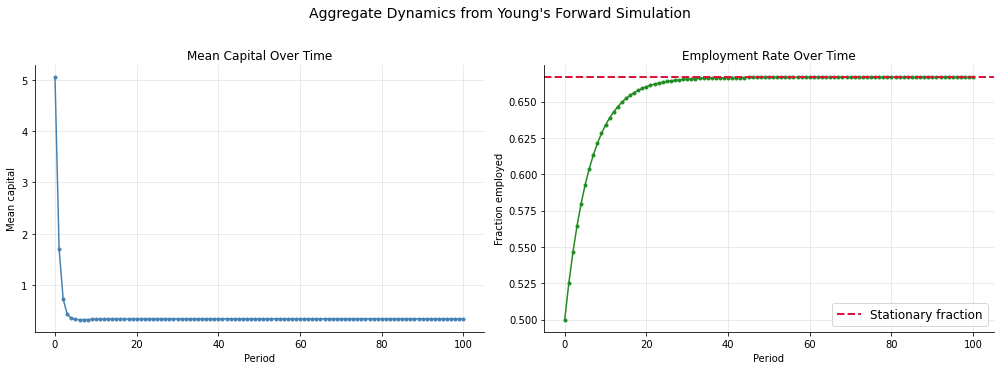

In [17]:
# Plot aggregate dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mean_k_history, 'o-', markersize=3, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Mean capital')
axes[0].set_title('Mean Capital Over Time')

axes[1].plot(frac_employed, 'o-', markersize=3, color='forestgreen', linewidth=1.5)
axes[1].axhline((1 - pi_uu) / ((1 - pi_ee) + (1 - pi_uu)), color='crimson',
               linestyle='--', linewidth=2, label='Stationary fraction')
axes[1].set_xlabel('Period')
axes[1].set_ylabel('Fraction employed')
axes[1].set_title('Employment Rate Over Time')
axes[1].legend(fontsize=12)

plt.suptitle('Aggregate Dynamics from Young\'s Forward Simulation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

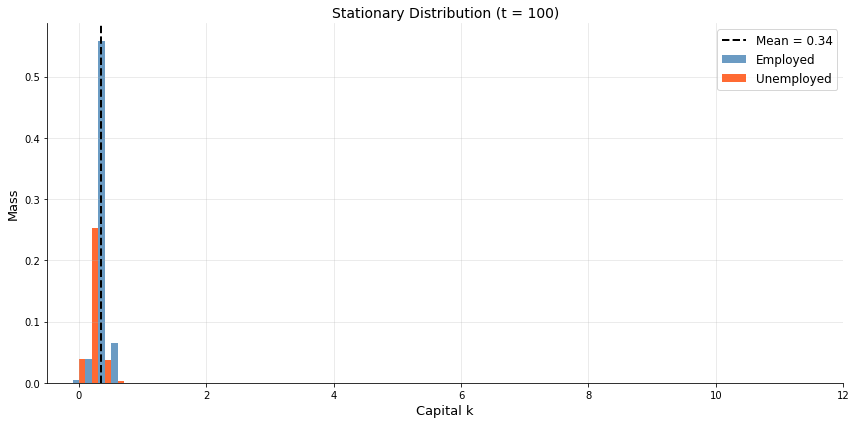


Stationary Distribution Statistics:
  Overall mean capital:     0.3414
  Mean capital (employed):  0.4096
  Mean capital (unemployed):0.2049
  Fraction employed:        0.6667
  Fraction unemployed:      0.3333
  Total mass:               1.000000  (should be 1.0)


In [18]:
# Final stationary-ish distribution
h_final = hist_history[-1]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(k_grid - 0.05, h_final[:, 0], width=0.1, alpha=0.8, color='steelblue', label='Employed')
ax.bar(k_grid + 0.05, h_final[:, 1], width=0.1, alpha=0.8, color='orangered', label='Unemployed')
ax.axvline(mean_k_history[-1], color='black', linewidth=2, linestyle='--',
           label=f'Mean = {mean_k_history[-1]:.2f}')
ax.set_xlabel('Capital k', fontsize=13)
ax.set_ylabel('Mass', fontsize=13)
ax.set_title(f'Stationary Distribution (t = {T})', fontsize=14)
ax.set_xlim(-0.5, 12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Distributional statistics
total_mass_e = h_final[:, 0].sum()
total_mass_u = h_final[:, 1].sum()
mean_k_e = np.average(k_grid, weights=h_final[:, 0]) if total_mass_e > 0 else 0
mean_k_u = np.average(k_grid, weights=h_final[:, 1]) if total_mass_u > 0 else 0

print(f"\nStationary Distribution Statistics:")
print(f"  Overall mean capital:     {mean_k_history[-1]:.4f}")
print(f"  Mean capital (employed):  {mean_k_e:.4f}")
print(f"  Mean capital (unemployed):{mean_k_u:.4f}")
print(f"  Fraction employed:        {total_mass_e:.4f}")
print(f"  Fraction unemployed:      {total_mass_u:.4f}")
print(f"  Total mass:               {h_final.sum():.6f}  (should be 1.0)")

## 13. The Cascading Fork: One Cell Splits into Four

The 2D Young step in section 12 already combines the **capital lottery** (split off-grid $k'$ between $k_J$ and $k_{J+1}$) with the **shock fork** (transition from $\varepsilon$ to $\varepsilon'$ via $\pi_{\varepsilon\varepsilon'}$).  This section makes the two-stage cascade explicit on a single source bin, matching Figure~4.6 of the script and slide~14c of the L10 deck ("One Cell Splits Into Four").

**Setup (matches the script's worked example).**  One source mass $m=0.05$ at $(k, \varepsilon=L)$.  Capital lottery weights $\omega=0.6$, $1-\omega=0.4$.  Shock fork $\pi_{LL}=0.9$, $\pi_{LH}=0.1$.

**Expected leaves** (product of stage-1 and stage-2 weights):
- $(k_J, L)$: $0.6 \times 0.9 \times 0.05 = 0.027$
- $(k_J, H)$: $0.6 \times 0.1 \times 0.05 = 0.003$
- $(k_{J+1}, L)$: $0.4 \times 0.9 \times 0.05 = 0.018$
- $(k_{J+1}, H)$: $0.4 \times 0.1 \times 0.05 = 0.002$

Sum: $0.027 + 0.003 + 0.018 + 0.002 = 0.05 = m$.  Mass conservation by construction.


In [ ]:
# Cascading fork: one source cell -> four destination leaves.
# Stage 1 (capital lottery): split mass between bracketing grid points.
# Stage 2 (shock fork): split each piece across reachable next-period eps'.

m_source = 0.05            # mass at the source bin
omega = 0.6                # capital-lottery weight on the lower bracket k_J
pi = np.array([[0.9, 0.1], # pi[L, L'], pi[L, H'] -- the source eps is L
               [0.2, 0.8]])

# Source state index: eps_src = 0 (low)
eps_src = 0

# The four leaf masses, by hand:
leaves = {
    '(k_J,    L)': omega       * pi[eps_src, 0] * m_source,
    '(k_J,    H)': omega       * pi[eps_src, 1] * m_source,
    '(k_J+1,  L)': (1 - omega) * pi[eps_src, 0] * m_source,
    '(k_J+1,  H)': (1 - omega) * pi[eps_src, 1] * m_source,
}

for label, mass in leaves.items():
    print(f'  {label:<14s} = {mass:.4f}')

total = sum(leaves.values())
print(f'\n  sum of leaves = {total:.4f}   (source mass m = {m_source:.4f})')

# Stage-1 mean preservation: omega * k_J + (1 - omega) * k_{J+1} = k'.
# Demonstrate with a concrete grid:
k_J, k_Jp1 = 2.0, 4.0
k_prime    = omega * k_J + (1 - omega) * k_Jp1
print(f'\n  stage-1 conditional mean: omega*k_J + (1-omega)*k_(J+1) = {k_prime:.3f}')
print('  (matches the off-grid policy choice k_prime by construction)')


## Conclusion

This notebook demonstrated Young's (2010) non-stochastic simulation method:

1. **Core algorithm**: Linear interpolation to redistribute mass on a fixed grid
2. **Mean preservation**: The method preserves the mean of the distribution exactly
3. **Higher moments**: Variance and median are approximated; finer grids → better accuracy
4. **No sampling noise**: Unlike panel simulation, which requires tens of thousands of agents
5. **Forward simulation**: Can propagate distributions forward in time using policy functions
6. **Idiosyncratic shocks**: Naturally extends to multiple employment/income states

### Bridge to `11_Continuum_of_Agents_DEQN`
- The toy object `h(k)` becomes a stacked histogram over $(\eta, b)$ blocks
- The hand-set policy function becomes a policy network output $b'(\eta, b, x_t^{agg})$
- The weighted mean calculation becomes exact market clearing via the histogram dot product with network-implied savings

### Next steps
- Combine with value function iteration (or neural networks) to solve full heterogeneous agent models
- Use as the distribution propagation step inside DEQN training loops
- See the companion slides: `08_Heterogeneous_Agents_Youngs_Method.pdf`

### Reference
Young, E.R. (2010). "Solving the incomplete markets model with aggregate uncertainty using the Krusell–Smith algorithm and non-stochastic simulations." *Journal of Economic Dynamics and Control*, 34(1), 36–41.